# Lab 7 and 8: Detailed Step-by-Step Analysis
---

## Task 1: Load and Inspect Data

### 1.1 Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

### 1.2 Load Dataset

In [10]:
df = pd.read_csv('headbrain11.csv')
print(df.head())   

   Head Size(cm^3)  Brain Weight(grams)
0             4512                 1530
1             3738                 1297
2             4261                 1335
3             3777                 1282
4             4177                 1590


### 1.3 Display First 5 Rows (Head)

In [11]:
df.head()

,Head Size(cm^3),Brain Weight(grams)
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


### 1.4 Data Information (Info)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Head Size(cm^3)      237 non-null    int64
 1   Brain Weight(grams)  237 non-null    int64
dtypes: int64(2)
memory usage: 3.8 KB


### 1.5 Check for Missing Values

In [13]:
df.isnull().sum()

Head Size(cm^3)        0
Brain Weight(grams)    0
dtype: int64

### 1.6 Summary Statistics (Describe)

In [14]:
df.describe()

,Head Size(cm^3),Brain Weight(grams)
count,237.000000,237.000000
mean,3633.991561,1282.873418
std,365.261422,120.340446
min,2720.000000,955.000000
25%,3389.000000,1207.000000
50%,3614.000000,1280.000000
75%,3876.000000,1350.000000
max,4747.000000,1635.000000


--- 
## Task 2: Data Cleaning

### 2.1 Rename Columns

In [15]:
df.columns = ['Head_size', 'Brain_weight']
df.head()

,Head_size,Brain_weight
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


**Question:** Why is renaming useful?

**Answer:** It makes column names compatible with code and regression formulas.

--- 
## Task 3: EDA Visualizations

### 3.1 Individual Scatterplot

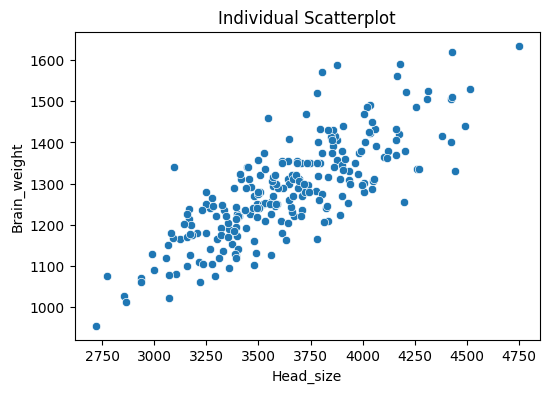

In [16]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Head_size', y='Brain_weight', data=df)
plt.title('Individual Scatterplot')
plt.show()

### 3.2 Individual Regression Plot

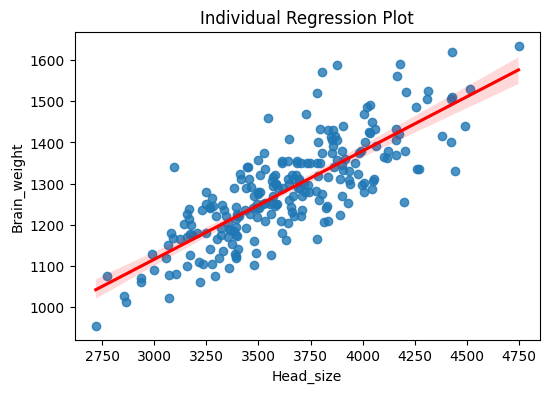

In [17]:
plt.figure(figsize=(6, 4))
sns.regplot(x='Head_size', y='Brain_weight', data=df, line_kws={'color':'red'})
plt.title('Individual Regression Plot')
plt.show()

### 3.3 Individual Histograms

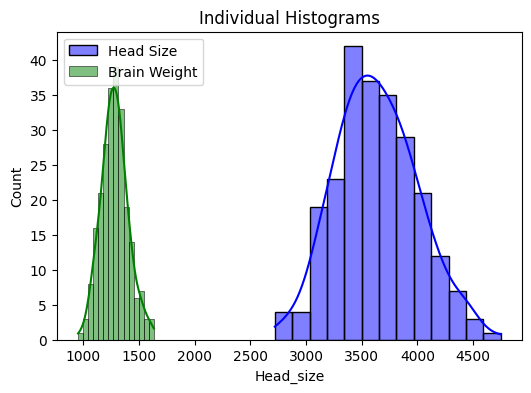

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Head_size'], kde=True, color='blue', label='Head Size')
sns.histplot(df['Brain_weight'], kde=True, color='green', label='Brain Weight')
plt.title('Individual Histograms')
plt.legend()
plt.show()

### 3.4 Individual Boxplot

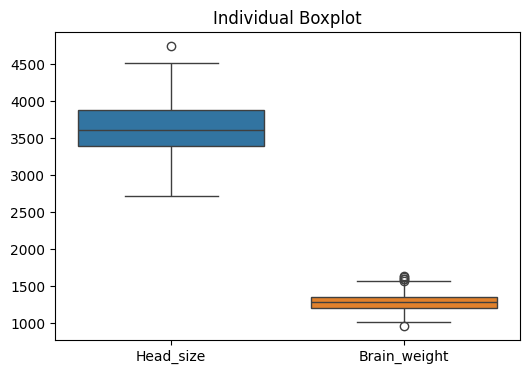

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[['Head_size', 'Brain_weight']])
plt.title('Individual Boxplot')
plt.show()

### 3.5 Combined Grid Visualization (Subplots)
Using `plt.subplots` to display all visualizations in a single figure for comparison.

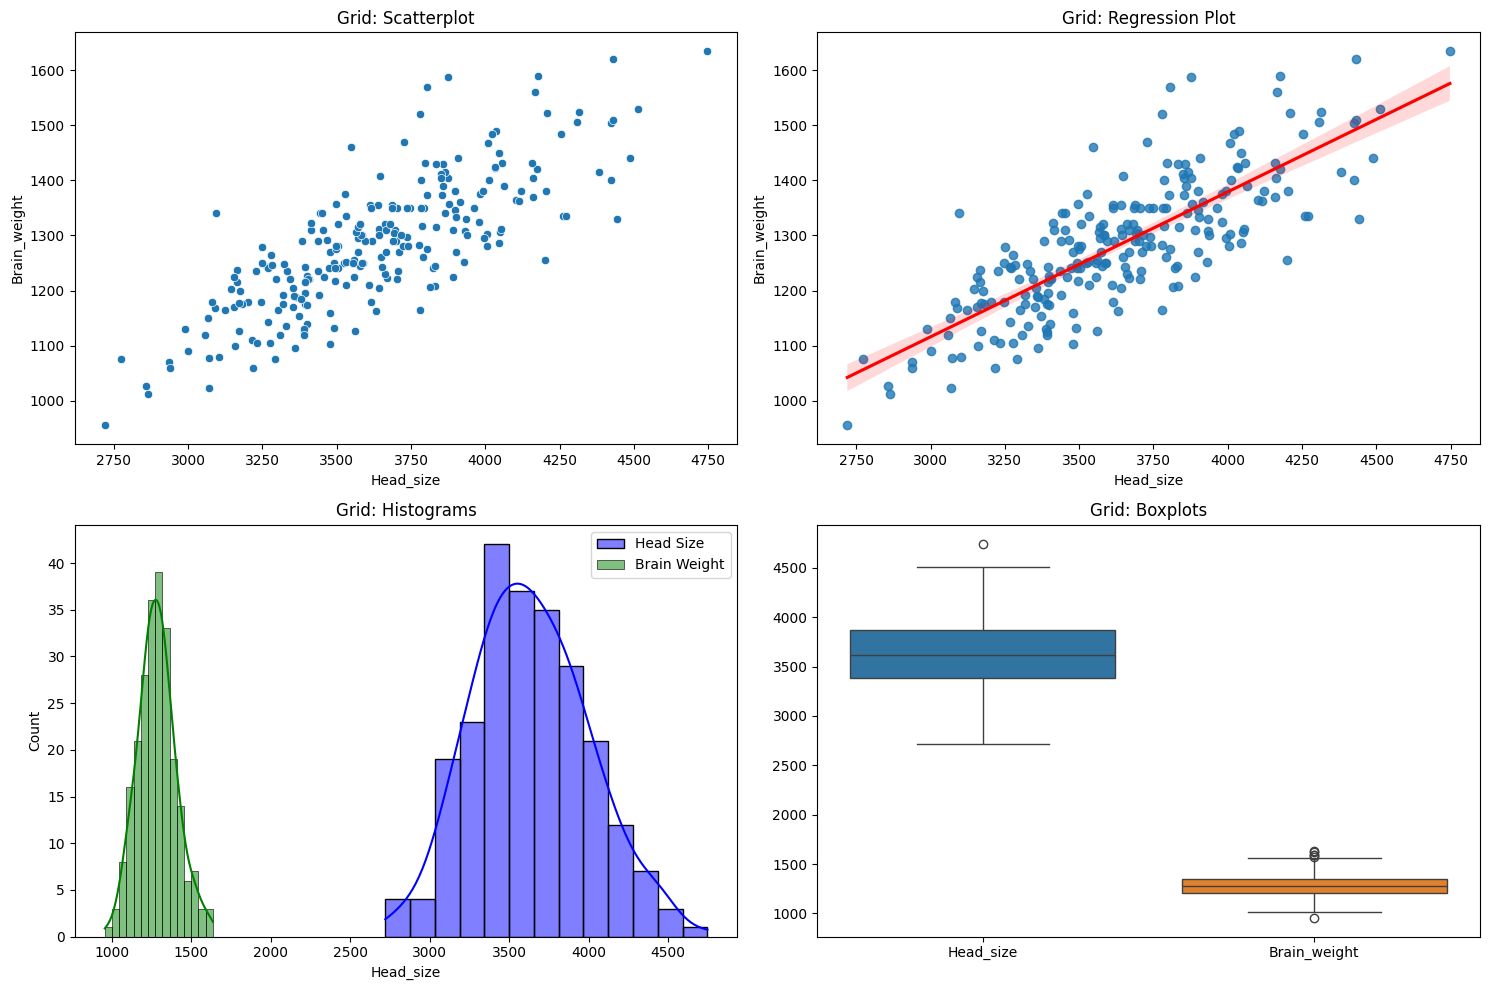

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Row 0, Col 0: Scatterplot
sns.scatterplot(x='Head_size', y='Brain_weight', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Grid: Scatterplot')

# Row 0, Col 1: Regression Plot
sns.regplot(x='Head_size', y='Brain_weight', data=df, line_kws={'color':'red'}, ax=axes[0, 1])
axes[0, 1].set_title('Grid: Regression Plot')

# Row 1, Col 0: Histograms
sns.histplot(df['Head_size'], kde=True, color='blue', label='Head Size', ax=axes[1, 0])
sns.histplot(df['Brain_weight'], kde=True, color='green', label='Brain Weight', ax=axes[1, 0])
axes[1, 0].set_title('Grid: Histograms')
axes[1, 0].legend()

# Row 1, Col 1: Boxplots
sns.boxplot(data=df[['Head_size', 'Brain_weight']], ax=axes[1, 1])
axes[1, 1].set_title('Grid: Boxplots')

plt.tight_layout()
plt.show()

--- 
## Task 4: Regression Modeling

### 4.1 Fit Linear Regression Model

In [21]:
model = smf.ols('Brain_weight ~ Head_size', data=df).fit()

### 4.2 Model Summary

In [22]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Brain_weight   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     416.5
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           5.96e-54
Time:                        12:47:53   Log-Likelihood:                -1350.3
No. Observations:                 237   AIC:                             2705.
Df Residuals:                     235   BIC:                             2711.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    325.5734     47.141      6.906      0.0

### 4.3 Evaluate Significance and Equation

In [23]:
print(f"Equation: Y = {model.params[0]:.2f} + {model.params[1]:.4f}*X")
print(f"R-squared: {model.rsquared:.4f}")

Equation: Y = 325.57 + 0.2634*X
R-squared: 0.6393


/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_75938/951960548.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Equation: Y = {model.params[0]:.2f} + {model.params[1]:.4f}*X")


--- 
## Task 5: Interpretation

### 5.1 Explain Metrics

In [24]:
print("- R-squared: Proportion of variance explained.")
print("- P-value: Significance indicator (Target < 0.05).")
print("- F-statistic: Overall model significance.")

- R-squared: Proportion of variance explained.
- P-value: Significance indicator (Target < 0.05).
- F-statistic: Overall model significance.


### 5.2 Final Conclusion

In [25]:
print(f"Conclusion: With R-squared of {model.rsquared:.3f}, the model explains {model.rsquared*100:.1f}% of data variation.")

Conclusion: With R-squared of 0.639, the model explains 63.9% of data variation.
